# Unit 02｜代理模型与不确定性

## Goal

在同一一维候选池上比较 GP 后验标准差与 RF 集成分歧，并在 query 固定后诊断误差。

本 Notebook 是确定性的人工教学实验，不是学习者已完成的研究，
也不是粘合剂实验结果。


## Setup

人工目标函数只用于离线 Oracle。GP 使用固定核参数，避免教程输出随优化器变化。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

X_all = np.linspace(0.0, 10.0, 31).reshape(-1, 1)
oracle_values = np.sin(X_all[:, 0]) + 0.08 * X_all[:, 0]
initial_indices = np.array([0, 6, 12, 18, 24, 30])
pool_indices = np.setdiff1d(np.arange(len(X_all)), initial_indices)

X_labeled = X_all[initial_indices]
y_labeled = oracle_values[initial_indices]
X_pool = X_all[pool_indices]
print("labeled/pool:", X_labeled.shape, X_pool.shape)


labeled/pool: (6, 1) (25, 1)


## Steps

按顺序执行。每个变量第一次出现时，先确认它的类型、形状和标签权限。


### 1. GP 输出均值与后验标准差

核参数固定；标准差的含义依赖该核与噪声假设。


In [2]:
kernel = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * RBF(1.2, length_scale_bounds="fixed")
    + WhiteKernel(0.03, noise_level_bounds="fixed")
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    optimizer=None,
    normalize_y=True,
)
gp.fit(X_labeled, y_labeled)
gp_mean, gp_std = gp.predict(X_pool, return_std=True)
print("GP output shapes:", gp_mean.shape, gp_std.shape)


GP output shapes: (25,) (25,)


### 2. RF 多成员产生启发式分歧

每个成员使用不同种子；输出矩阵的行是成员、列是候选。


In [3]:
seeds = [11, 22, 33, 44, 55]
rf_predictions = []
for seed in seeds:
    member = RandomForestRegressor(
        n_estimators=80,
        max_depth=4,
        random_state=seed,
        n_jobs=1,
    )
    member.fit(X_labeled, y_labeled)
    rf_predictions.append(member.predict(X_pool))

rf_matrix = np.vstack(rf_predictions)
rf_mean = rf_matrix.mean(axis=0)
rf_std = rf_matrix.std(axis=0)
print("RF prediction matrix:", rf_matrix.shape)


RF prediction matrix: (5, 25)


### 3. 先固定 query，再做离线误差诊断

两个一次性 query 都固定后，campaign 结束；evaluator 才查看整池误差，且结果不再返回策略。


In [4]:
pool_ids = np.array([
    f"U{index:02d}" for index in pool_indices
])

def select_with_tie_break(score, ids):
    order = np.lexsort((ids.astype(str), -np.asarray(score)))
    return int(order[0])

gp_query_local = select_with_tie_break(gp_std, pool_ids)
rf_query_local = select_with_tie_break(rf_std, pool_ids)
gp_query_global = int(pool_indices[gp_query_local])
rf_query_global = int(pool_indices[rf_query_local])

def offline_absolute_error(hidden_truth, prediction):
    return np.abs(hidden_truth - prediction)

# 事后 evaluator：两个 query 已固定，且本单元不再继续选点。
offline_pool_truth = oracle_values[pool_indices]
gp_error = offline_absolute_error(
    offline_pool_truth,
    gp_mean,
)
rf_error = offline_absolute_error(
    offline_pool_truth,
    rf_mean,
)
diagnosis = pd.DataFrame({
    "candidate_x": X_pool[:, 0],
    "gp_std": gp_std,
    "gp_abs_error": gp_error,
    "rf_disagreement": rf_std,
    "rf_abs_error": rf_error,
})
print("GP query x:", float(X_all[gp_query_global, 0]))
print("RF query x:", float(X_all[rf_query_global, 0]))
print(diagnosis.sort_values("gp_std", ascending=False).head(5).to_string(index=False))


GP query x: 1.0
RF query x: 2.333333333333333
 candidate_x   gp_std  gp_abs_error  rf_disagreement  rf_abs_error
         1.0 0.337908      0.278473         0.057949      0.732684
         9.0 0.337908      0.105139         0.057601      0.027801
         7.0 0.331318      0.106903         0.068936      0.723579
         3.0 0.331318      0.014559         0.095254      0.198066
         5.0 0.330967      0.156591         0.022653      0.426587


### 4. 可视化预测与分歧

阴影用于比较模型行为，不宣称是经过验证的 95% 预测区间。


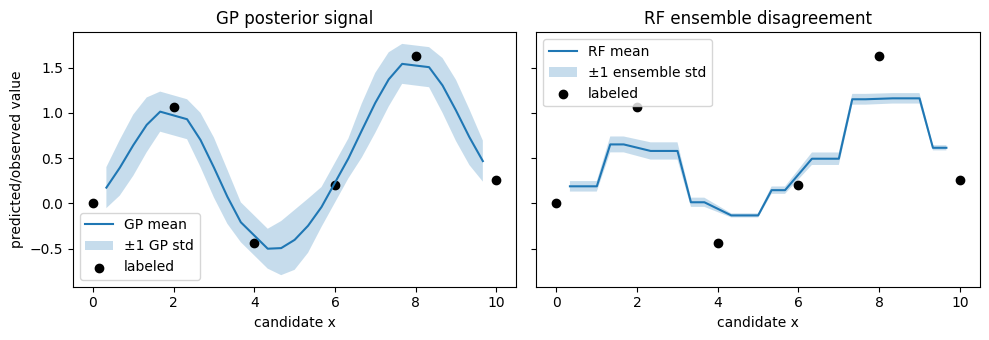

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].plot(X_pool[:, 0], gp_mean, label="GP mean")
axes[0].fill_between(
    X_pool[:, 0],
    gp_mean - gp_std,
    gp_mean + gp_std,
    alpha=0.25,
    label="±1 GP std",
)
axes[0].scatter(X_labeled[:, 0], y_labeled, color="black", label="labeled")
axes[0].set_title("GP posterior signal")
axes[0].set_xlabel("candidate x")
axes[0].set_ylabel("predicted/observed value")
axes[0].legend()

axes[1].plot(X_pool[:, 0], rf_mean, label="RF mean")
axes[1].fill_between(
    X_pool[:, 0],
    rf_mean - rf_std,
    rf_mean + rf_std,
    alpha=0.25,
    label="±1 ensemble std",
)
axes[1].scatter(X_labeled[:, 0], y_labeled, color="black", label="labeled")
axes[1].set_title("RF ensemble disagreement")
axes[1].set_xlabel("candidate x")
axes[1].legend()
plt.tight_layout()
plt.show()


## Checks

这些断言检查形状、预算和无重复等机械条件；通过断言不代表研究结论已经成立。


In [6]:
assert gp_mean.shape == (len(pool_indices),)
assert rf_matrix.shape == (5, len(pool_indices))
assert np.all(gp_std >= 0)
assert np.all(rf_std >= 0)
assert gp_query_global not in initial_indices
assert rf_query_global not in initial_indices
print("Unit 02 checks passed.")


Unit 02 checks passed.


## Next Steps

完成不确定性来源练习。Unit 03 将保持预测表不变，只更换采集函数。
